Gathering images from source folder (Blood_Cells_Cancer)...
Found 0 candidate images across classes.
Valid images: 0, Invalid images: 0
Classes detected: []
Empty DataFrame
Columns: [count]
Index: []


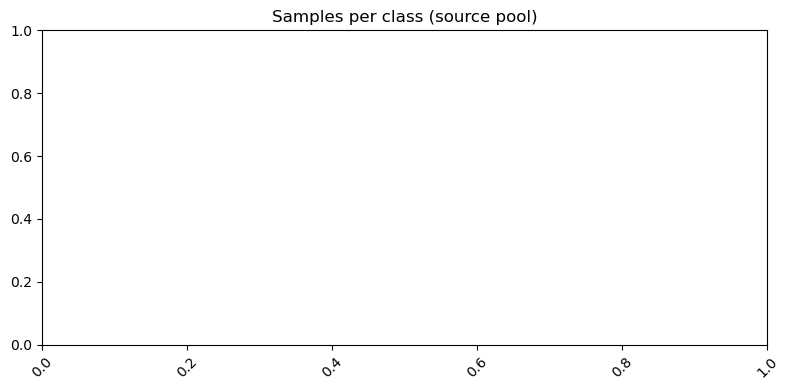

<Figure size 1200x300 with 0 Axes>

Moved counts: {'Train': 0, 'Val': 0, 'Test': 0}
After split counts:
Train: {'Benign': 685, 'early Pre-B': 685, 'Pre-B': 685, 'Pro-B': 685}
Val:   {'Benign': 76, 'early Pre-B': 146, 'Pre-B': 143, 'Pro-B': 119}
Test:  {'Benign': 78, 'early Pre-B': 148, 'Pre-B': 144, 'Pro-B': 120}


In [ ]:
import os, shutil, random, math
from pathlib import Path
from PIL import Image, ImageFilter
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
import pandas as pd

random_seed = 42
random.seed(random_seed)
np.random.seed(random_seed)

# ---------- UPDATE: use the new raw data folder as the SOURCE root ----------
path = kagglehub.dataset_download("dhruvpanchal1/inria-rooftop-segmentation-dataset-1024x1024-png")

# We'll create Train/Val/Test under the same folder
DATA_ROOT = SOURCE_ROOT
TRAIN_DIR = DATA_ROOT / "Train"
VAL_DIR   = DATA_ROOT / "Val"
TEST_DIR  = DATA_ROOT / "Test"   # will be created by the script

# valid extensions
VALID_EXT = {".jpg", ".jpeg", ".png", ".bmp", ".tiff"}

def is_image_valid(p: Path):
    try:
        with Image.open(p) as im:
            im.verify()   # basic integrity check
        return True
    except Exception:
        return False

# gather files FROM SOURCE_ROOT (ignore any already-created Train/Val/Test folders)
def gather_all_images_from_source(source_root: Path):
    records = []  # (fullpath, class_name)
    # iterate class dirs in the source root
    for class_dir in sorted([p for p in source_root.iterdir() if p.is_dir() and p.name.lower() not in {"train","val","test"}]):
        # support both structures: class_dir/images/*  OR class_dir/*
        candidate_dirs = [class_dir / "images", class_dir]
        for dd in candidate_dirs:
            if dd.exists() and dd.is_dir():
                for p in dd.rglob("*"):
                    if p.is_file() and p.suffix.lower() in VALID_EXT:
                        records.append((p.resolve(), class_dir.name))
                break
    return records

print("Gathering images from source folder (Blood_Cells_Cancer)...")
all_records = gather_all_images_from_source(SOURCE_ROOT)
print(f"Found {len(all_records)} candidate images across classes.")

# Validate files
invalid = []
valid_records = []
for p, cls in all_records:
    if is_image_valid(Path(p)):
        valid_records.append((Path(p), cls))
    else:
        invalid.append((Path(p), cls))

print(f"Valid images: {len(valid_records)}, Invalid images: {len(invalid)}")
if invalid:
    print("Invalid samples (first 10):", invalid[:10])
    # Optionally delete invalids (uncomment to actually remove):
    # for p, _ in invalid:
    #     p.unlink()

# classes (from valid records)
classes = sorted(list({cls for _, cls in valid_records}))
print("Classes detected:", classes)

# counts per class (in the source pool)
counts = Counter([cls for _, cls in valid_records])
df_counts = pd.DataFrame.from_dict(counts, orient='index', columns=['count']).sort_values('count', ascending=False)
print(df_counts)

# Countplot (EDA)
plt.figure(figsize=(8,4))
sns.barplot(x=df_counts.index, y='count', data=df_counts.reset_index().rename(columns={'index':'class'}))
plt.title("Samples per class (source pool)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Show one sample per class for quick visual check
plt.figure(figsize=(12,3))
for i, cls in enumerate(classes):
    candidates = [p for p,c in valid_records if c==cls]
    if not candidates:
        continue
    p = random.choice(candidates)
    im = Image.open(p).convert("RGB").resize((224,224))
    plt.subplot(1, len(classes), i+1)
    plt.imshow(im)
    plt.axis('off')
    plt.title(cls)
plt.suptitle("One sample per class (source)")
plt.show()

# --- Now split into Train / Val / Test (70/15/15) by moving files from source class folders ---
split_ratios = (0.7, 0.15, 0.15)  # train, val, test

# Prepare target directories: create Train/Val/Test and class subfolders with images/ subdir
for top in ("Train", "Val", "Test"):
    for cls in classes:
        target_images_dir = DATA_ROOT / top / cls / "images"
        target_images_dir.mkdir(parents=True, exist_ok=True)

# Group valid records by class and move items
by_class = {cls: [p for p,c in valid_records if c==cls] for cls in classes}
moved_counts = {'Train':0, 'Val':0, 'Test':0}

for cls, paths in by_class.items():
    random.shuffle(paths)
    n = len(paths)
    n_train = int(math.floor(n * split_ratios[0]))
    n_val   = int(math.floor(n * split_ratios[1]))
    n_test  = n - n_train - n_val
    idx = 0
    # move train portion
    for p in paths[idx: idx+n_train]:
        dest = DATA_ROOT / "Train" / cls / "images" / p.name
        # if dest exists (name collision) we rename to avoid overwrite:
        if dest.exists():
            dest = DATA_ROOT / "Train" / cls / "images" / f"{p.stem}_moved_{random.getrandbits(32)}{p.suffix}"
        shutil.move(str(p), str(dest))
        moved_counts['Train'] += 1
    idx += n_train
    # move val portion
    for p in paths[idx: idx+n_val]:
        dest = DATA_ROOT / "Val" / cls / "images" / p.name
        if dest.exists():
            dest = DATA_ROOT / "Val" / cls / "images" / f"{p.stem}_moved_{random.getrandbits(32)}{p.suffix}"
        shutil.move(str(p), str(dest))
        moved_counts['Val'] += 1
    idx += n_val
    # move test portion
    for p in paths[idx: idx+n_test]:
        dest = DATA_ROOT / "Test" / cls / "images" / p.name
        if dest.exists():
            dest = DATA_ROOT / "Test" / cls / "images" / f"{p.stem}_moved_{random.getrandbits(32)}{p.suffix}"
        shutil.move(str(p), str(dest))
        moved_counts['Test'] += 1

print("Moved counts:", moved_counts)

# print counts after split
def count_images_in(root):
    counts = {}
    root = Path(root)
    for clsdir in sorted([p for p in root.iterdir() if p.is_dir()]):
        imgs_dir = clsdir / "images"
        if imgs_dir.exists():
            counts[clsdir.name] = len([p for p in imgs_dir.iterdir() if p.suffix.lower() in VALID_EXT])
        else:
            counts[clsdir.name] = 0
    return counts

print("After split counts:")
print("Train:", count_images_in(DATA_ROOT/"Train"))
print("Val:  ", count_images_in(DATA_ROOT/"Val"))
print("Test: ", count_images_in(DATA_ROOT/"Test"))


In [ ]:
# Cell B: Simple augmentations (blur, noise, horizontal flip) and save augmented images to Train until classes balanced
from PIL import ImageOps, ImageEnhance
import uuid

# Use the same DATA_ROOT (we created Train under SOURCE_ROOT)
DATA_ROOT = Path("./Blood_Cells_Cancer")
TRAIN_ROOT = DATA_ROOT / "Train"
VALID_EXT = {".jpg", ".jpeg", ".png", ".bmp", ".tiff"}

def add_gaussian_noise(np_img, mean=0, std=10):
    noise = np.random.normal(mean, std, np_img.shape).astype(np.int16)
    noisy = np_img.astype(np.int16) + noise
    noisy = np.clip(noisy, 0, 255).astype(np.uint8)
    return noisy

# derive classes from Train folder (in case they differ)
classes = sorted([p.name for p in TRAIN_ROOT.iterdir() if p.is_dir()])
if not classes:
    raise RuntimeError(f"No class folders found in {TRAIN_ROOT}. Run Cell A first or check paths.")
print("Classes to augment:", classes)

# get counts and compute max
train_counts = {cls: len(list((TRAIN_ROOT/cls/"images").glob("*"))) for cls in classes}
max_count = max(train_counts.values()) if train_counts else 0
print("Train counts before augmentation:", train_counts, "-> target:", max_count)

for cls in classes:
    imgs_dir = TRAIN_ROOT / cls / "images"
    cur = len(list(imgs_dir.glob("*")))
    needed = max_count - cur
    if needed <= 0:
        continue
    files = list(imgs_dir.glob("*"))
    if not files:
        continue
    idx = 0
    while needed > 0:
        src = files[idx % len(files)]
        try:
            img = Image.open(src).convert("RGB")
        except Exception:
            idx += 1
            continue
        # choose augmentation deterministically based on idx to vary ops
        mode = idx % 3
        if mode == 0:
            # blur
            aug = img.filter(ImageFilter.GaussianBlur(radius=2))
        elif mode == 1:
            # horizontal flip
            aug = ImageOps.mirror(img)
        else:
            # add gaussian noise
            arr = np.array(img)
            noisy = add_gaussian_noise(arr, std=12)
            aug = Image.fromarray(noisy)
        # save with unique name to avoid collisions
        new_name = f"{src.stem}_aug_{uuid.uuid4().hex[:8]}{src.suffix}"
        dest = imgs_dir / new_name
        aug.save(dest)
        needed -= 1
        idx += 1

print("Augmentation done. New train counts:")
print({cls: len(list((TRAIN_ROOT/cls/"images").glob("*"))) for cls in classes})


In [3]:
# Cell C: PyTorch datasets + dataloaders
import torch
from torchvision import transforms, datasets
from torch.utils.data import DataLoader, WeightedRandomSampler

IMAGE_SIZE = 224
BATCH_SIZE = 16
NUM_WORKERS = 4
PIN_MEMORY = True
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

imagenet_mean = [0.485, 0.456, 0.406]
imagenet_std  = [0.229, 0.224, 0.225]

train_tf = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ColorJitter(brightness=0.1, contrast=0.1, saturation=0.1),
    transforms.ToTensor(),
    transforms.Normalize(imagenet_mean, imagenet_std)
])

val_tf = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(imagenet_mean, imagenet_std)
])

train_dataset = datasets.ImageFolder(DATA_ROOT/"Train", transform=train_tf)
val_dataset   = datasets.ImageFolder(DATA_ROOT/"Val", transform=val_tf)
test_dataset  = datasets.ImageFolder(DATA_ROOT/"Test", transform=val_tf)

print("Classes (ImageFolder):", train_dataset.classes)
print("Train len:", len(train_dataset), "Val len:", len(val_dataset), "Test len:", len(test_dataset))

# optional: weighted sampler to handle imbalance (if not using saved augmentation)
labels = [y for _, y in train_dataset.samples]
class_sample_count = np.array([labels.count(i) for i in range(len(train_dataset.classes))])
weights = 1. / class_sample_count
samples_weights = np.array([weights[t] for t in labels])
sampler = WeightedRandomSampler(weights=samples_weights, num_samples=len(samples_weights), replacement=True)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, sampler=sampler,
                          num_workers=NUM_WORKERS, pin_memory=PIN_MEMORY)

val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False,
                        num_workers=NUM_WORKERS, pin_memory=PIN_MEMORY)

test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False,
                         num_workers=NUM_WORKERS, pin_memory=PIN_MEMORY)


Classes (ImageFolder): ['Benign', 'Pre-B', 'Pro-B', 'early Pre-B']
Train len: 2740 Val len: 484 Test len: 490


In [4]:
# Cell D (UPDATED): model, training loop, early stopping, AMP, final test evaluation
import os
import torch
from torchvision import models
from torch import nn
import copy, time
from tqdm import tqdm
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix

# --- Safety checks: ensure we have datasets/loaders from previous cells ---
# If train_dataset / loaders weren't created in Cell C (for any reason), attempt to build them quickly.
try:
    _ = train_dataset  # noqa: F821
    _ = train_loader
    _ = val_loader
    _ = test_loader
except NameError:
    # Minimal fallback: recreate ImageFolder datasets + DataLoaders using DATA_ROOT, transforms that were defined in Cell C.
    from torchvision import datasets, transforms
    print("train_dataset or loaders not found — attempting to recreate using DATA_ROOT and transforms (make sure Cell C ran).")
    train_dataset = datasets.ImageFolder(DATA_ROOT / "Train", transform=train_tf)
    val_dataset   = datasets.ImageFolder(DATA_ROOT / "Val",   transform=val_tf)
    test_dataset  = datasets.ImageFolder(DATA_ROOT / "Test",  transform=val_tf)
    # recreate WeightedRandomSampler as before
    labels = [y for _, y in train_dataset.samples]
    class_sample_count = np.array([labels.count(i) for i in range(len(train_dataset.classes))])
    weights = 1. / class_sample_count
    samples_weights = np.array([weights[t] for t in labels])
    from torch.utils.data import WeightedRandomSampler, DataLoader
    sampler = WeightedRandomSampler(weights=samples_weights, num_samples=len(samples_weights), replacement=True)
    train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, sampler=sampler, num_workers=NUM_WORKERS, pin_memory=PIN_MEMORY)
    val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, pin_memory=PIN_MEMORY)
    test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, pin_memory=PIN_MEMORY)

# --- Config / hyperparameters ---
NUM_CLASSES = len(train_dataset.classes)
EPOCHS = 25
SAVE_PATH = "googlenet_best.pth"
LIGHT_SAVE = "googlenet_best_state.pth"   # smaller file with only state_dict
USE_AMP = True                            # mixed precision (set False if you experience issues)
EARLY_STOPPING_PATIENCE = 6               # stop training if no val_acc improvement for N epochs

print(f"Device: {DEVICE}, Num classes: {NUM_CLASSES}, Train samples: {len(train_dataset)}, Val: {len(val_dataset)}, Test: {len(test_dataset)}")

# --- Build model (GoogLeNet) and replace heads ---
googlenet = models.googlenet(pretrained=True, aux_logits=True, transform_input=False)

# Replace main classifier
in_features = googlenet.fc.in_features
googlenet.fc = nn.Sequential(
    nn.Dropout(0.5),
    nn.Linear(in_features, 512),
    nn.ReLU(inplace=True),
    nn.BatchNorm1d(512),
    nn.Dropout(0.4),
    nn.Linear(512, NUM_CLASSES)
)

# Replace auxiliary heads if present (ensure aux heads output correct num classes)
if getattr(googlenet, "aux1", None) is not None and hasattr(googlenet.aux1, "fc"):
    aux1_in = googlenet.aux1.fc.in_features
    googlenet.aux1.fc = nn.Linear(aux1_in, NUM_CLASSES)
if getattr(googlenet, "aux2", None) is not None and hasattr(googlenet.aux2, "fc"):
    aux2_in = googlenet.aux2.fc.in_features
    googlenet.aux2.fc = nn.Linear(aux2_in, NUM_CLASSES)

googlenet = googlenet.to(DEVICE)

# --- Loss / optimizer / scheduler ---
criterion = nn.CrossEntropyLoss()

# split params into backbone vs head for differential LR (head = new fc and aux)
base_params = []
head_params = []
for name, param in googlenet.named_parameters():
    if ("fc" in name) or ("aux" in name):
        head_params.append(param)
    else:
        base_params.append(param)

optimizer = torch.optim.SGD([
    {"params": base_params, "lr": 1e-4},
    {"params": head_params, "lr": 1e-3}
], momentum=0.9, weight_decay=1e-4)

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=3, verbose=True)

# --- Training and evaluation helpers with optional AMP ---
scaler = torch.cuda.amp.GradScaler(enabled=USE_AMP)

def train_one_epoch(model, loader, criterion, optimizer, device, use_aux=True):
    model.train()
    running_loss = 0.0
    running_corrects = 0
    total = 0
    pbar = tqdm(loader, desc="Train", leave=False)
    for inputs, labels in pbar:
        inputs = inputs.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)
        optimizer.zero_grad()
        with torch.cuda.amp.autocast(enabled=USE_AMP):
            outputs = model(inputs)
            # handle aux outputs (tuple) when training with aux_logits
            if use_aux and isinstance(outputs, tuple):
                main_out = outputs[0]
                aux_outs = outputs[1:]
                loss = criterion(main_out, labels)
                for aux in aux_outs:
                    if aux is not None:
                        loss = loss + 0.3 * criterion(aux, labels)
                preds = torch.argmax(main_out, dim=1)
            else:
                if isinstance(outputs, tuple):
                    outputs = outputs[0]
                loss = criterion(outputs, labels)
                preds = torch.argmax(outputs, dim=1)
        # backward with scaler if AMP on
        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()
        running_loss += loss.item() * inputs.size(0)
        running_corrects += torch.sum(preds == labels).item()
        total += inputs.size(0)
        pbar.set_postfix(loss=running_loss/total, acc=running_corrects/total)
    return running_loss / total, running_corrects / total

def evaluate(model, loader, criterion, device):
    model.eval()
    running_loss = 0.0
    preds_all = []
    labels_all = []
    with torch.no_grad():
        pbar = tqdm(loader, desc="Eval ", leave=False)
        for inputs, labels in pbar:
            inputs = inputs.to(device, non_blocking=True)
            labels = labels.to(device, non_blocking=True)
            outputs = model(inputs)
            if isinstance(outputs, tuple):
                outputs = outputs[0]
            loss = criterion(outputs, labels)
            preds = torch.argmax(outputs, dim=1)
            running_loss += loss.item() * inputs.size(0)
            preds_all.append(preds.cpu().numpy())
            labels_all.append(labels.cpu().numpy())
            pbar.set_postfix(loss=running_loss / (sum(len(x) for x in labels_all)))
    preds_all = np.concatenate(preds_all) if preds_all else np.array([])
    labels_all = np.concatenate(labels_all) if labels_all else np.array([])
    epoch_loss = running_loss / len(labels_all) if len(labels_all) else 0.0
    epoch_acc = (preds_all == labels_all).mean() if len(labels_all) else 0.0
    return epoch_loss, epoch_acc, preds_all, labels_all

# --- Training loop with early stopping and checkpointing ---
best_acc = 0.0
best_weights = copy.deepcopy(googlenet.state_dict())
history = {"train_loss":[], "train_acc":[], "val_loss":[], "val_acc":[]}

no_improve_epochs = 0
use_aux = True

for epoch in range(1, EPOCHS + 1):
    t0 = time.time()
    train_loss, train_acc = train_one_epoch(googlenet, train_loader, criterion, optimizer, DEVICE, use_aux=use_aux)
    val_loss, val_acc, _, _ = evaluate(googlenet, val_loader, criterion, DEVICE)
    scheduler.step(val_loss)
    history["train_loss"].append(train_loss); history["train_acc"].append(train_acc)
    history["val_loss"].append(val_loss); history["val_acc"].append(val_acc)
    epoch_time = time.time() - t0
    print(f"Epoch {epoch}/{EPOCHS} — time {epoch_time:.1f}s | train_loss: {train_loss:.4f}, train_acc: {train_acc:.4f} | val_loss: {val_loss:.4f}, val_acc: {val_acc:.4f}")
    # checkpoint best
    if val_acc > best_acc + 1e-6:
        best_acc = val_acc
        best_weights = copy.deepcopy(googlenet.state_dict())
        torch.save({
            "model_state_dict": best_weights,
            "optimizer_state_dict": optimizer.state_dict(),
            "class_names": train_dataset.classes,
            "history": history,
            "epoch": epoch,
            "val_acc": val_acc
        }, SAVE_PATH)
        # also save lighter state_dict-only file
        torch.save(best_weights, LIGHT_SAVE)
        print(f"--> New best model (val_acc={val_acc:.4f}) saved to {SAVE_PATH}")
        no_improve_epochs = 0
    else:
        no_improve_epochs += 1
        print(f"No improvement for {no_improve_epochs} epoch(s).")
    # early stopping
    if no_improve_epochs >= EARLY_STOPPING_PATIENCE:
        print(f"Early stopping triggered (no improvement in {EARLY_STOPPING_PATIENCE} epochs).")
        break

# --- Final evaluation on test set using best weights ---
googlenet.load_state_dict(best_weights)
test_loss, test_acc, preds_test, labels_test = evaluate(googlenet, test_loader, criterion, DEVICE)
print("FINAL TEST -- Loss: {:.4f}, Acc: {:.4f}".format(test_loss, test_acc))

# classification report + confusion matrix (nice readable output)
print("\nClassification report (test):")
print(classification_report(labels_test, preds_test, target_names=train_dataset.classes, zero_division=0))
print("\nConfusion matrix (rows=true, cols=pred):")
print(confusion_matrix(labels_test, preds_test))

# optionally save a final full checkpoint with metadata
final_ckpt = {
    "model_state_dict": best_weights,
    "class_names": train_dataset.classes,
    "history": history,
    "test_loss": test_loss,
    "test_acc": test_acc
}
torch.save(final_ckpt, "googlenet_final_checkpoint.pth")
print("Saved final checkpoint: googlenet_final_checkpoint.pth")


Device: cuda, Num classes: 4, Train samples: 2740, Val: 484, Test: 490


c:\Users\ADMIN\anaconda3\envs\tf2.10\lib\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
c:\Users\ADMIN\anaconda3\envs\tf2.10\lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=GoogLeNet_Weights.IMAGENET1K_V1`. You can also use `weights=GoogLeNet_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
c:\Users\ADMIN\anaconda3\envs\tf2.10\lib\site-packages\torchvision\models\googlenet.py:341: UserWarning: auxiliary heads in the pretrained googlenet model are NOT pretrained, so make sure to train them
  warnings.warn(
c:\Users\ADMIN\anaconda3\envs\tf2.10\lib\site-packages\torch\optim\lr_scheduler.py:62: UserWarning: The verbose parameter is d

Epoch 1/25 — time 50.7s | train_loss: 1.7495, train_acc: 0.7409 | val_loss: 0.1286, val_acc: 0.9649
--> New best model (val_acc=0.9649) saved to googlenet_best.pth


Epoch 2/25 — time 44.7s | train_loss: 0.5338, train_acc: 0.9026 | val_loss: 0.0694, val_acc: 0.9793
--> New best model (val_acc=0.9793) saved to googlenet_best.pth


Epoch 3/25 — time 42.7s | train_loss: 0.3489, train_acc: 0.9310 | val_loss: 0.0593, val_acc: 0.9793
No improvement for 1 epoch(s).


...

Epoch 10/25 — time 35.5s | train_loss: 0.1558, train_acc: 0.9646 | val_loss: 0.0360, val_acc: 0.9855
No improvement for 3 epoch(s).


Epoch 11/25 — time 37.5s | train_loss: 0.1222, train_acc: 0.9741 | val_loss: 0.0380, val_acc: 0.9855
No improvement for 4 epoch(s).


Epoch 12/25 — time 41.0s | train_loss: 0.1444, train_acc: 0.9657 | val_loss: 0.0413, val_acc: 0.9835
No improvement for 5 epoch(s).


Epoch 13/25 — time 39.7s | train_loss: 0.1246, train_acc: 0.9723 | val_loss: 0.0312, val_acc: 0.9897
No improvement for 6 epoch(s).
Early stopping triggered (no improvement in 6 epochs).


FINAL TEST -- Loss: 0.0198, Acc: 0.9980

Classification report (test):
              precision    recall  f1-score   support

      Benign       0.99      1.00      0.99        78
       Pre-B       1.00      1.00      1.00       144
       Pro-B       1.00      1.00      1.00       120
 early Pre-B       1.00      0.99      1.00       148

    accuracy                           1.00       490
   macro avg       1.00      1.00      1.00       490
weighted avg       1.00      1.00      1.00       490


Confusion matrix (rows=true, cols=pred):
[[ 78   0   0   0]
 [  0 144   0   0]
 [  0   0 120   0]
 [  1   0   0 147]]
Saved final checkpoint: googlenet_final_checkpoint.pth


In [5]:
import os
import shutil
import random
from pathlib import Path
import csv
from typing import List
from PIL import Image

# ---------- CONFIG ----------
random.seed(42)            # reproducible split
DATA_ROOT = Path("./Data_Brain")    # contains Train/, Val/, (maybe Test/)
TRAIN_SPLIT_NAME = "Train"
TEST_SPLIT_NAME = "Test"
VAL_SPLIT_NAME = "Val"
SPLIT_PERCENT = 0.15      # fraction of Train to move into Test (per-class)
VALID_EXT = {".jpg", ".jpeg", ".png", ".bmp", ".tiff"}
OUTPUT_ROOT = Path("./Data_Brain_filtered")
MANIFEST_PATH = OUTPUT_ROOT / "manifest.csv"
SKIPPED_LOG = OUTPUT_ROOT / "skipped.log"
# -----------------------------

def possible_image_files(p: Path) -> List[Path]:
    """Return list of image files under path p (non-recursive if p/images exists else check p)."""
    res = []
    if (p / "images").exists():
        folder = p / "images"
    else:
        folder = p
    for ext in VALID_EXT:
        res.extend(list(folder.glob(f"*{ext}")))
        res.extend(list(folder.glob(f"*{ext.upper()}")))
    return sorted(res)

def find_label_for_image(img_path: Path) -> Path:
    """
    Try to find the .txt label for the given image path.
    Returns Path if found, else None.
    """
    stem = img_path.stem
    candidates = []

    # If image path contains 'images', replace with 'labels' at that level
    parts = list(img_path.parts)
    if "images" in parts:
        idx = parts.index("images")
        parts_lab = parts.copy()
        parts_lab[idx] = "labels"
        # candidate label path (same name)
        cand = Path(*parts_lab).parent / f"{stem}.txt"
        candidates.append(cand)

    # same folder as image
    candidates.append(img_path.parent / f"{stem}.txt")

    # class-level labels folder (if images folder present, go up one level)
    if img_path.parent.name == "images":
        class_folder = img_path.parent.parent
    else:
        class_folder = img_path.parent
    candidates.append(class_folder / "labels" / f"{stem}.txt")

    for c in candidates:
        if c.exists():
            return c
    return None

def ensure_dir(p: Path):
    p.mkdir(parents=True, exist_ok=True)

def build_test_split_from_train_move():
    """
    Move SPLIT_PERCENT of Train images (per-class) into DATA_ROOT/Test/<class>/(images,labels)
    """
    src_train = DATA_ROOT / TRAIN_SPLIT_NAME
    dst_test = DATA_ROOT / TEST_SPLIT_NAME

    if not src_train.exists():
        print(f"[ERROR] Train folder not found at: {src_train}")
        return

    print("Creating Test split by MOVING samples from Train...")
    for class_dir in sorted([d for d in src_train.iterdir() if d.is_dir()]):
        cls = class_dir.name
        img_candidates = possible_image_files(class_dir)
        n = len(img_candidates)
        if n == 0:
            print(f"  [WARN] No images found for class '{cls}' in Train - skipping")
            continue

        n_test = int(round(SPLIT_PERCENT * n))
        # ensure at least 1 selected if there are enough images, but don't take all
        if n_test < 1 and n >= 2:
            n_test = 1
        if n_test >= n:
            n_test = max(1, n - 1)

        sampled = random.sample(img_candidates, n_test)
        moved = 0
        skipped_missing_label = 0
        failed = 0

        # Prepare destination folders under DATA_ROOT/Test/<class>/(images,labels)
        dst_images_folder = dst_test / cls / "images"
        dst_labels_folder = dst_test / cls / "labels"
        ensure_dir(dst_images_folder)
        ensure_dir(dst_labels_folder)

        for img in sampled:
            lbl = find_label_for_image(img)
            if lbl is None:
                skipped_missing_label += 1
                print(f"    [SKIP] No label for sampled image {img} (class {cls}) -- not moved")
                continue

            try:
                # move image
                dst_img_path = dst_images_folder / img.name
                shutil.move(str(img), str(dst_img_path))
                # move label (if it's inside train folder structure it will be moved, else copy then remove original)
                # If label is inside the same subtree, move preserves it; otherwise move as best-effort.
                dst_lbl_path = dst_labels_folder / lbl.name
                # Ensure original label still exists (may be same path as image folder level)
                if lbl.exists():
                    shutil.move(str(lbl), str(dst_lbl_path))
                else:
                    # label disappeared somehow; try to log and continue
                    print(f"    [WARN] Label {lbl} not found during move for image {img}")
                    failed += 1
                    continue
                moved += 1
            except Exception as e:
                print(f"    [ERROR] Failed to move {img} or {lbl}: {e}")
                failed += 1
                continue

        print(f"  Class '{cls}': train_count={n}, intended_test={n_test}, moved={moved}, skipped_no_label={skipped_missing_label}, errors={failed}")

    print("Test split (move) done.")

def filter_and_build_manifest():
    """Scan Train/Val/Test, verify labels, copy into OUTPUT_ROOT and write manifest + skipped log"""
    SPLITS = [TRAIN_SPLIT_NAME, VAL_SPLIT_NAME, TEST_SPLIT_NAME]

    # detect classes across splits
    classes = set()
    for split in SPLITS:
        src_split = DATA_ROOT / split
        if not src_split.exists():
            continue
        for p in src_split.iterdir():
            if p.is_dir():
                classes.add(p.name)
    classes = sorted(classes)
    print("Detected class folders (source):", classes)

    # prepare output folders
    ensure_dir(OUTPUT_ROOT)
    for split in SPLITS:
        for cls in classes:
            ensure_dir(OUTPUT_ROOT / "images" / split / cls)
            ensure_dir(OUTPUT_ROOT / "labels" / split / cls)

    manifest_rows = []
    skipped = []

    for split in SPLITS:
        src_split = DATA_ROOT / split
        if not src_split.exists():
            print(f"Warning: source split folder not found: {src_split} -- skipping")
            continue
        for class_dir in sorted([d for d in src_split.iterdir() if d.is_dir()]):
            cls = class_dir.name
            img_files = possible_image_files(class_dir)
            for img_path in img_files:
                label_path = find_label_for_image(img_path)
                if label_path is None:
                    skipped.append(str(img_path))
                    print(f"[SKIP] no label found for image: {img_path}")
                    continue
                # read label
                try:
                    with open(label_path, "r", encoding="utf-8") as fh:
                        lines = [ln.strip() for ln in fh if ln.strip()]
                except Exception as e:
                    skipped.append(str(img_path))
                    print(f"[SKIP] cannot read label {label_path} for image {img_path}: {e}")
                    continue
                if len(lines) == 0:
                    skipped.append(str(img_path))
                    print(f"[SKIP] empty label file {label_path} for image {img_path}")
                    continue

                # copy image and label into OUTPUT_ROOT structure (we keep filtered copy separate)
                dst_img = OUTPUT_ROOT / "images" / split / cls / img_path.name
                dst_lbl = OUTPUT_ROOT / "labels" / split / cls / (Path(label_path).stem + ".txt")
                try:
                    shutil.copy2(img_path, dst_img)
                    shutil.copy2(label_path, dst_lbl)
                except Exception as e:
                    skipped.append(str(img_path))
                    print(f"[SKIP] copy failed for {img_path} / {label_path}: {e}")
                    continue

                # parse label lines to extract class ids (if formatted like: class x y w h)
                classes_in_file = []
                for ln in lines:
                    parts = ln.split()
                    if len(parts) >= 1:
                        try:
                            cls_id = int(float(parts[0]))
                        except:
                            cls_id = parts[0]
                        classes_in_file.append(cls_id)

                manifest_rows.append({
                    "split": split,
                    "class": cls,
                    "orig_image": str(img_path),
                    "orig_label": str(label_path),
                    "out_image": str(dst_img),
                    "out_label": str(dst_lbl),
                    "num_boxes": len(classes_in_file),
                    "classes_in_boxes": ";".join(map(str, classes_in_file))
                })

    # Write manifest.csv
    ensure_dir(OUTPUT_ROOT)
    with open(MANIFEST_PATH, "w", newline="", encoding="utf-8") as csvf:
        fieldnames = ["split","class","orig_image","orig_label","out_image","out_label","num_boxes","classes_in_boxes"]
        writer = csv.DictWriter(csvf, fieldnames=fieldnames)
        writer.writeheader()
        for r in manifest_rows:
            writer.writerow(r)

    # Write skipped log
    with open(SKIPPED_LOG, "w", encoding="utf-8") as f:
        for s in skipped:
            f.write(s + "\n")

    print(f"Filtering done. Kept pairs: {len(manifest_rows)}. Skipped images: {len(skipped)}")
    print(f"Manifest: {MANIFEST_PATH}. Skipped log: {SKIPPED_LOG}")

if __name__ == "__main__":
    # 1) Move samples from Train -> Test
    build_test_split_from_train_move()

    # 2) Run the filter + manifest builder (copies validated pairs into OUTPUT_ROOT)
    filter_and_build_manifest()


Creating Test split by MOVING samples from Train...
    [SKIP] No label for sampled image Data_Brain\Train\Glioma\images\gg (803).jpg (class Glioma) -- not moved
    [SKIP] No label for sampled image Data_Brain\Train\Glioma\images\Tr-gl_0915.jpg (class Glioma) -- not moved
    [SKIP] No label for sampled image Data_Brain\Train\Glioma\images\Tr-gl_0497.jpg (class Glioma) -- not moved
    [SKIP] No label for sampled image Data_Brain\Train\Glioma\images\gg (723).jpg (class Glioma) -- not moved
    [SKIP] No label for sampled image Data_Brain\Train\Glioma\images\gg (393).jpg (class Glioma) -- not moved
    [SKIP] No label for sampled image Data_Brain\Train\Glioma\images\Tr-gl_0308.jpg (class Glioma) -- not moved
    [SKIP] No label for sampled image Data_Brain\Train\Glioma\images\Tr-gl_0063.jpg (class Glioma) -- not moved
    [SKIP] No label for sampled image Data_Brain\Train\Glioma\images\gg (621).jpg (class Glioma) -- not moved
    [SKIP] No label for sampled image Data_Brain\Train\Gliom

In [6]:
# Cell 2: sample images per class, draw YOLO boxes (normalized -> pixels), save samples, create dataset.yaml
import os
from pathlib import Path
from PIL import Image, ImageDraw, ImageFont
import random
import yaml

# ---------- CONFIG ----------
OUTPUT_ROOT = Path("./Data_Brain_filtered")
SAMPLES_OUT = OUTPUT_ROOT / "samples"
SAMPLES_PER_CLASS = 3            # images per class to show
IMAGE_EXT = (".jpg", ".jpeg", ".png", ".bmp", ".tiff")
DATASET_YAML = OUTPUT_ROOT / "dataset.yaml"
CLASS_NAMES = sorted([p.name for p in (OUTPUT_ROOT / "images" / "Train").iterdir() if p.is_dir()])  # infer classes
# If you want to force a class order, set CLASS_NAMES = ['Meningioma','NoTumor','Pituitary','Gliom']
print("Detected classes for samples:", CLASS_NAMES)
# -----------------------------

SAMPLES_OUT.mkdir(parents=True, exist_ok=True)

def read_yolo_label(label_path: Path):
    """Return list of boxes as tuples (class_id, x_center_norm, y_center_norm, w_norm, h_norm)."""
    boxes = []
    try:
        with open(label_path, "r", encoding="utf-8") as f:
            for ln in f:
                ln = ln.strip()
                if not ln:
                    continue
                parts = ln.split()
                # expect at least 5 elements
                if len(parts) < 5:
                    continue
                cls_id = int(float(parts[0]))
                xcn = float(parts[1]); ycn = float(parts[2]); wn = float(parts[3]); hn = float(parts[4])
                boxes.append((cls_id, xcn, ycn, wn, hn))
    except Exception:
        # bad label
        return []
    return boxes

def draw_boxes_on_image(img_path: Path, label_path: Path, out_path: Path, class_names: list):
    img = Image.open(img_path).convert("RGB")
    W, H = img.size
    draw = ImageDraw.Draw(img)
    boxes = read_yolo_label(label_path)
    # load default font (always available)
    try:
        font = ImageFont.load_default()
    except Exception:
        font = None

    for (cls_id, xcn, ycn, wn, hn) in boxes:
        # convert normalized to pixel coords and clip
        cx = max(0.0, min(1.0, xcn)) * W
        cy = max(0.0, min(1.0, ycn)) * H
        bw = max(0.0, min(1.0, wn)) * W
        bh = max(0.0, min(1.0, hn)) * H
        x0 = int(round(cx - bw/2))
        y0 = int(round(cy - bh/2))
        x1 = int(round(cx + bw/2))
        y1 = int(round(cy + bh/2))
        # clip to image
        x0 = max(0, min(W-1, x0))
        y0 = max(0, min(H-1, y0))
        x1 = max(0, min(W-1, x1))
        y1 = max(0, min(H-1, y1))
        # color and label
        color = (255, 0, 0)  # red
        draw.rectangle([x0, y0, x1, y1], outline=color, width=2)
        label_text = str(class_names[cls_id]) if 0 <= cls_id < len(class_names) else f"class_{cls_id}"

        # --- robust text measurement: try textbbox(), fallback to font.getsize(), fallback to estimate ---
        try:
            bbox = draw.textbbox((0, 0), label_text, font=font)
            tw = bbox[2] - bbox[0]
            th = bbox[3] - bbox[1]
        except Exception:
            try:
                if font is not None:
                    tw, th = font.getsize(label_text)
                else:
                    raise Exception("no font")
            except Exception:
                tw, th = (len(label_text) * 6, 11)  # crude estimate

        # draw text background (ensure it stays within image vertically)
        ty0 = max(0, y0 - th - 4)
        draw.rectangle([x0, ty0, x0 + tw + 4, ty0 + th + 4], fill=color)
        draw.text((x0 + 2, ty0 + 2), label_text, fill=(255, 255, 255), font=font)

    img.save(out_path)

# For each class sample SAMPLES_PER_CLASS images from OUTPUT_ROOT/images/Train/<class> (fallback to Val/Test)
for cls in CLASS_NAMES:
    collected = []
    for split in ["Train", "Val", "Test"]:
        imgs_folder = OUTPUT_ROOT / "images" / split / cls
        if imgs_folder.exists():
            imgs = [p for p in imgs_folder.iterdir() if p.suffix.lower() in IMAGE_EXT]
            collected.extend([(split, p) for p in imgs])
    if not collected:
        print(f"No images found for class {cls} in filtered output.")
        continue
    sampled = random.sample(collected, min(SAMPLES_PER_CLASS, len(collected)))
    for i, (split, img_p) in enumerate(sampled, start=1):
        # corresponding label in OUTPUT_ROOT/labels/<split>/<cls>/<stem>.txt
        label_p = OUTPUT_ROOT / "labels" / split / cls / (img_p.stem + ".txt")
        if not label_p.exists():
            print(f"[WARNING] expected label missing for sample {img_p} -> skipping drawing")
            continue
        out_file = SAMPLES_OUT / f"{cls}_sample_{split}_{i}{img_p.suffix}"
        draw_boxes_on_image(img_p, label_p, out_file, CLASS_NAMES)
        print(f"Saved sample with boxes: {out_file}")

# Create dataset.yaml for YOLOv8 (point to train/val/test image folders)
# YOLOv8 can accept folder paths; we'll point to output images/train etc. (it will search recursively)
dataset_dict = {
    "train": str((OUTPUT_ROOT / "images" / "Train").resolve()),
    "val":   str((OUTPUT_ROOT / "images" / "Val").resolve()),
    "test":  str((OUTPUT_ROOT / "images" / "Test").resolve()),
    "names": CLASS_NAMES
}

with open(DATASET_YAML, "w", encoding="utf-8") as f:
    yaml.dump(dataset_dict, f, sort_keys=False)

print(f"dataset.yaml saved to: {DATASET_YAML}")
print("Done. Samples saved in:", SAMPLES_OUT)
print("You can now train YOLOv8 with a command similar to:")
print(f"  yolo task=detect mode=train model=yolov8n.pt data={DATASET_YAML} epochs=50 imgsz=640 batch=16")


Detected classes for samples: ['Glioma', 'Meningioma', 'No Tumor', 'Pituitary']
Saved sample with boxes: Data_Brain_filtered\samples\Glioma_sample_Train_1.jpg
Saved sample with boxes: Data_Brain_filtered\samples\Glioma_sample_Test_2.jpg
Saved sample with boxes: Data_Brain_filtered\samples\Glioma_sample_Test_3.jpg
Saved sample with boxes: Data_Brain_filtered\samples\Meningioma_sample_Test_1.jpg
Saved sample with boxes: Data_Brain_filtered\samples\Meningioma_sample_Train_2.jpg
Saved sample with boxes: Data_Brain_filtered\samples\Meningioma_sample_Train_3.jpg
Saved sample with boxes: Data_Brain_filtered\samples\No Tumor_sample_Train_1.jpg
Saved sample with boxes: Data_Brain_filtered\samples\No Tumor_sample_Test_2.jpg
Saved sample with boxes: Data_Brain_filtered\samples\No Tumor_sample_Train_3.jpg
Saved sample with boxes: Data_Brain_filtered\samples\Pituitary_sample_Test_1.jpg
Saved sample with boxes: Data_Brain_filtered\samples\Pituitary_sample_Test_2.jpg
Saved sample with boxes: Data_Bra

In [7]:
# Cell 1: create data.yaml (no augment) and data2.yaml (with augment), and print counts
import os
from pathlib import Path
import yaml
from collections import defaultdict

OUTPUT_ROOT = Path("./Data_Brain_filtered")
IMAGES_ROOT = OUTPUT_ROOT / "images"
LABELS_ROOT = OUTPUT_ROOT / "labels"
DATA_YAML = OUTPUT_ROOT / "data.yaml"
DATA2_YAML = OUTPUT_ROOT / "data2.yaml"

# Discover splits and classes (assume Train and Val exist under images)
splits = {}
for split in ("Train", "Val", "Test"):
    split_dir = IMAGES_ROOT / split
    if split_dir.exists():
        # YOLOv8 accepts a folder for train/val where subfolders are classes or flat.
        splits[split] = str(split_dir.resolve())
    else:
        splits[split] = None

# Infer classes from Train folder (fallback to Val if Train missing)
class_dirs = []
if (IMAGES_ROOT / "Train").exists():
    class_dirs = sorted([p.name for p in (IMAGES_ROOT / "Train").iterdir() if p.is_dir()])
elif (IMAGES_ROOT / "Val").exists():
    class_dirs = sorted([p.name for p in (IMAGES_ROOT / "Val").iterdir() if p.is_dir()])
else:
    # Try test
    if (IMAGES_ROOT / "Test").exists():
        class_dirs = sorted([p.name for p in (IMAGES_ROOT / "Test").iterdir() if p.is_dir()])

if not class_dirs:
    raise RuntimeError(f"No class subfolders found under {IMAGES_ROOT}/Train or Val or Test. Check earlier steps.")

print("Detected classes:", class_dirs)
num_classes = len(class_dirs)

# Count images and labels per split/class
VALID_IMG_EXT = {".jpg", ".jpeg", ".png", ".bmp", ".tiff"}
def count_images_labels(base_images_root: Path, base_labels_root: Path, splits_to_check=("Train","Val")):
    summary = defaultdict(lambda: {"images":0, "labels":0})
    for split in splits_to_check:
        for cls in class_dirs:
            imgs_dir = base_images_root / split / cls
            lbls_dir = base_labels_root / split / cls
            images = []
            labels = []
            if imgs_dir.exists():
                images = [p for p in imgs_dir.iterdir() if p.suffix.lower() in VALID_IMG_EXT and p.is_file()]
            if lbls_dir.exists():
                labels = [p for p in lbls_dir.iterdir() if p.suffix.lower() == ".txt" and p.is_file()]
            summary[f"{split}/{cls}"]["images"] = len(images)
            summary[f"{split}/{cls}"]["labels"] = len(labels)
    return summary

summary = count_images_labels(IMAGES_ROOT, LABELS_ROOT, splits_to_check=("Train","Val"))
# Print a readable summary and totals
total_images = 0
total_labels = 0
print("\nCounts per split/class (Train & Val):")
for key, v in summary.items():
    print(f" {key}: images={v['images']}, labels={v['labels']}")
    total_images += v['images']
    total_labels += v['labels']
print(f"Total (Train+Val): images={total_images}, labels={total_labels}\n")

# Create data.yaml (augment disabled)
data_yaml_content = {
    "train": splits.get("Train"),
    "val": splits.get("Val"),
    "test": splits.get("Test"),
    "nc": num_classes,
    "names": class_dirs,
    # custom key to explicitly indicate augmentation disabled (YOLOv8 CLI uses training flags, but adding key is informative)
    "augment": False
}
with open(DATA_YAML, "w") as f:
    yaml.dump(data_yaml_content, f, sort_keys=False)
print(f"Created {DATA_YAML}")

# Create data2.yaml (augment enabled with example augmentation params)
# Note: YOLOv8 typically configures augmentation via CLI flags or a separate augment config.
# We'll include an 'augment_params' block for documentation/consumers of this yaml.
data2_yaml_content = {
    "train": splits.get("Train"),
    "val": splits.get("Val"),
    "test": splits.get("Test"),
    "nc": num_classes,
    "names": class_dirs,
    "augment": True,
    "augment_params": {
        "mosaic": True,
        "mixup": True,
        "hsv_h": 0.015,
        "hsv_s": 0.7,
        "hsv_v": 0.4,
        "flipud": 0.0,
        "fliplr": 0.5,
        "degrees": 10.0,
        "translate": 0.1,
        "scale": 0.5
    }
}
with open(DATA2_YAML, "w") as f:
    yaml.dump(data2_yaml_content, f, sort_keys=False)
print(f"Created {DATA2_YAML}")

print("\nData files ready. If you plan to use YOLOv8 CLI, use data.yaml to train without augmentations or data2.yaml with augment info.")


Detected classes: ['Glioma', 'Meningioma', 'No Tumor', 'Pituitary']

Counts per split/class (Train & Val):
 Train/Glioma: images=1153, labels=1153
 Train/Meningioma: images=1449, labels=1449
 Train/No Tumor: images=647, labels=647
 Train/Pituitary: images=1026, labels=1026
 Val/Glioma: images=135, labels=135
 Val/Meningioma: images=140, labels=140
 Val/No Tumor: images=98, labels=98
 Val/Pituitary: images=136, labels=136
Total (Train+Val): images=4784, labels=4784

Created Data_Brain_filtered\data.yaml
Created Data_Brain_filtered\data2.yaml

Data files ready. If you plan to use YOLOv8 CLI, use data.yaml to train without augmentations or data2.yaml with augment info.


In [8]:
# Cell 2: verify each image has a label and vice-versa for Train & Val; move unmatched to removed/
import os, shutil
from pathlib import Path

OUTPUT_ROOT = Path("./Data_Brain_filtered")
IMAGES_ROOT = OUTPUT_ROOT / "images"
LABELS_ROOT = OUTPUT_ROOT / "labels"
REMOVED_ROOT = OUTPUT_ROOT / "removed"
REMOVED_IMAGES = REMOVED_ROOT / "images"
REMOVED_LABELS = REMOVED_ROOT / "labels"

# make removed dirs
(REMOVED_IMAGES).mkdir(parents=True, exist_ok=True)
(REMOVED_LABELS).mkdir(parents=True, exist_ok=True)

VALID_IMG_EXT = {".jpg", ".jpeg", ".png", ".bmp", ".tiff"}

def gather_image_basenames(img_dir: Path):
    if not img_dir.exists():
        return {}
    res = {}
    for p in img_dir.iterdir():
        if not p.is_file(): continue
        if p.suffix.lower() in VALID_IMG_EXT:
            res[p.stem] = p
    return res

def gather_label_basenames(lbl_dir: Path):
    if not lbl_dir.exists():
        return {}
    res = {}
    for p in lbl_dir.iterdir():
        if not p.is_file(): continue
        if p.suffix.lower() == ".txt":
            res[p.stem] = p
    return res

# Process splits Train & Val (user required)
splits_to_check = ("Train", "Val")
report = []

for split in splits_to_check:
    print(f"\n=== Checking split: {split} ===")
    for class_dir in sorted((IMAGES_ROOT / split).iterdir() if (IMAGES_ROOT / split).exists() else []):
        cls = class_dir.name
        imgs_dir = IMAGES_ROOT / split / cls
        lbls_dir = LABELS_ROOT / split / cls
        img_map = gather_image_basenames(imgs_dir)
        lbl_map = gather_label_basenames(lbls_dir)
        img_keys = set(img_map.keys())
        lbl_keys = set(lbl_map.keys())

        only_images = sorted(list(img_keys - lbl_keys))
        only_labels = sorted(list(lbl_keys - img_keys))
        matched = sorted(list(img_keys & lbl_keys))

        # Move-only images to removed/images/<split>/<class>/
        if only_images:
            dst_dir = REMOVED_IMAGES / split / cls
            dst_dir.mkdir(parents=True, exist_ok=True)
            for stem in only_images:
                src = img_map[stem]
                dst = dst_dir / src.name
                try:
                    shutil.move(str(src), str(dst))
                    # To permanently delete instead of moving, uncomment:
                    # os.remove(src)
                except Exception as e:
                    print(f"Failed to move image {src}: {e}")
        # Move-only labels to removed/labels/<split>/<class>/
        if only_labels:
            dst_dir = REMOVED_LABELS / split / cls
            dst_dir.mkdir(parents=True, exist_ok=True)
            for stem in only_labels:
                src = lbl_map[stem]
                dst = dst_dir / src.name
                try:
                    shutil.move(str(src), str(dst))
                    # To permanently delete instead of moving, uncomment:
                    # os.remove(src)
                except Exception as e:
                    print(f"Failed to move label {src}: {e}")

        report.append({
            "split": split,
            "class": cls,
            "images_before": len(img_keys),
            "labels_before": len(lbl_keys),
            "matched": len(matched),
            "only_images_moved": len(only_images),
            "only_labels_moved": len(only_labels)
        })

# Print summary report
print("\nVerification & cleanup summary (Train & Val):")
total_before_images = total_before_labels = total_matched = total_only_images = total_only_labels = 0
for r in report:
    print(f" {r['split']}/{r['class']}: images={r['images_before']}, labels={r['labels_before']}, matched={r['matched']}, moved_images={r['only_images_moved']}, moved_labels={r['only_labels_moved']}")
    total_before_images += r['images_before']
    total_before_labels += r['labels_before']
    total_matched += r['matched']
    total_only_images += r['only_images_moved']
    total_only_labels += r['only_labels_moved']

print("\nTotals:")
print(f" Images before (Train+Val): {total_before_images}")
print(f" Labels before (Train+Val): {total_before_labels}")
print(f" Matched pairs kept: {total_matched}")
print(f" Images moved to {REMOVED_IMAGES}: {total_only_images}")
print(f" Labels moved to {REMOVED_LABELS}: {total_only_labels}")

print("\nNote: unmatched files were moved to the 'removed' folder under the filtered dataset.")
print("If you want to permanently delete them, edit the script and replace the move() with os.remove() as indicated in comments.")



=== Checking split: Train ===

=== Checking split: Val ===

Verification & cleanup summary (Train & Val):
 Train/Glioma: images=1153, labels=1153, matched=1153, moved_images=0, moved_labels=0
 Train/Meningioma: images=1449, labels=1449, matched=1449, moved_images=0, moved_labels=0
 Train/No Tumor: images=647, labels=647, matched=647, moved_images=0, moved_labels=0
 Train/Pituitary: images=1026, labels=1026, matched=1026, moved_images=0, moved_labels=0
 Val/Glioma: images=135, labels=135, matched=135, moved_images=0, moved_labels=0
 Val/Meningioma: images=140, labels=140, matched=140, moved_images=0, moved_labels=0
 Val/No Tumor: images=98, labels=98, matched=98, moved_images=0, moved_labels=0
 Val/Pituitary: images=136, labels=136, matched=136, moved_images=0, moved_labels=0

Totals:
 Images before (Train+Val): 4784
 Labels before (Train+Val): 4784
 Matched pairs kept: 4784
 Images moved to Data_Brain_filtered\removed\images: 0
 Labels moved to Data_Brain_filtered\removed\labels: 0

N

In [ ]:
# Cell 1: Train YOLOv8, evaluate on val/test, save and export best model
# Requirements: pip install ultralytics pyyaml
# Run this cell on machine with GPU; set GPUs via ULTRALYTICS env var or CLI if needed.

from pathlib import Path
from ultralytics import YOLO
import shutil
import json
import os

# ---------- CONFIG ----------
OUTPUT_ROOT = Path("./Data_Brain_filtered")        # cleaned dataset root from previous steps
DATA_YAML = OUTPUT_ROOT / "dataset.yaml"          # dataset yaml created earlier
SAVE_DIR = Path("./yolo_runs")                    # where to copy final artifacts
EXPERIMENT_NAME = "yolov8_brain_tumor"
# Training hyperparameters (tweak as needed)
MODEL_ARCH = "yolov8n.pt"     # start from pretrained small model; change to yolov8s/medium/large if you have GPUs
EPOCHS = 50
IMG_SIZE = 640
BATCH = 16
LR = 0.01
DEVICE = 0                    # GPU index or 'cpu' / '0' for first GPU
# -----------------------------

if not DATA_YAML.exists():
    raise FileNotFoundError(f"{DATA_YAML} not found. Make sure filtered dataset and dataset.yaml exist.")

# create output dir
SAVE_DIR.mkdir(parents=True, exist_ok=True)

# instantiate YOLO model (pretrained)
print("Loading YOLO model:", MODEL_ARCH)
model = YOLO(MODEL_ARCH)

# Train: ultralytics will create runs/train/exp folders and automatically save best.pt
print("Starting training... This will print progress from ultralytics.")
model.train(data=str(DATA_YAML),
            epochs=EPOCHS,
            imgsz=IMG_SIZE,
            batch=BATCH,
            lr0=LR,
            device=DEVICE,
            project=str(SAVE_DIR),
            name=EXPERIMENT_NAME,
            exist_ok=True,
            workers=8,
            save=True)  

# After training, find best.pt in runs/train/<EXPERIMENT_NAME>*
run_base = SAVE_DIR / EXPERIMENT_NAME
# ultralytics may create numbered exps; find latest matching name directory
def find_best_pt(project_dir: Path, experiment_name: str):
    # scan project_dir for subfolders starting with experiment_name
    candidates = [d for d in project_dir.iterdir() if d.is_dir() and d.name.startswith(experiment_name)]
    if not candidates:
        # also consider 'exp', 'exp2' etc
        candidates = [d for d in project_dir.iterdir() if d.is_dir()]
    # choose latest by mtime
    candidates = sorted(candidates, key=lambda d: d.stat().st_mtime, reverse=True)
    for d in candidates:
        best = d / "weights" / "best.pt"
        if best.exists():
            return best, d
    return None, None

best_pt, run_dir = find_best_pt(SAVE_DIR, EXPERIMENT_NAME)
if best_pt is None:
    print("Warning: best.pt not found automatically. Look into", SAVE_DIR)
else:
    print("Found best checkpoint:", best_pt)
    # copy best.pt to output root for convenience
    final_best = OUTPUT_ROOT / "yolov8_best.pt"
    shutil.copy2(best_pt, final_best)
    print("Copied best model to:", final_best)

# Evaluate (validation & test) using ultralytics model.val
# Reload model from best weights if available, else use last
eval_model = YOLO(str(final_best) if best_pt is not None else MODEL_ARCH)

print("Running evaluation (val) ...")
val_results = eval_model.val(data=str(DATA_YAML), imgsz=IMG_SIZE, batch=BATCH, device=DEVICE)
# ultralytics prints metrics; val_results is a list/dict-like object; save it
val_metrics_file = run_dir / "val_metrics.json" if run_dir else Path("val_metrics.json")
try:
    # the return includes best fitness and metrics; we save raw to JSON where possible
    with open(val_metrics_file, "w") as f:
        json.dump({"val_results": str(val_results)}, f, indent=2)
    print("Saved val metrics to:", val_metrics_file)
except Exception:
    pass

# Optionally run test evaluation if dataset.yaml includes 'test' and you want explicit metrics
print("Running evaluation (test) ...")
test_results = eval_model.val(data=str(DATA_YAML), split="test", imgsz=IMG_SIZE, batch=BATCH, device=DEVICE)
test_metrics_file = run_dir / "test_metrics.json" if run_dir else Path("test_metrics.json")
try:
    with open(test_metrics_file, "w") as f:
        json.dump({"test_results": str(test_results)}, f, indent=2)
    print("Saved test metrics to:", test_metrics_file)
except Exception:
    pass

# Export detector (optional): ONNX and TorchScript
export_dir = OUTPUT_ROOT / "yolo_exports"
export_dir.mkdir(parents=True, exist_ok=True)
print("Exporting model to TorchScript and ONNX (may take time)...")
try:
    # ultralytics export API: model.export(format="torchscript") — outputs are saved under runs/export
    eval_model.export(format="torchscript", imgsz=IMG_SIZE)
    eval_model.export(format="onnx", imgsz=IMG_SIZE)
    print("Export attempted (check runs/export for produced files).")
except Exception as e:
    print("Export failed or partially failed:", e)

print("YOLO training + evaluation pipeline completed. Best weights:", str(final_best) if best_pt else "Not found")


Loading YOLO model: yolov8n.pt
Starting training... This will print progress from ultralytics.


c:\Users\ADMIN\anaconda3\envs\tf2.10\lib\site-packages\requests\__init__.py:86: RequestsDependencyWarning: Unable to find acceptable character detection dependency (chardet or charset_normalizer).
  warnings.warn(


Ultralytics 8.3.221  Python-3.10.18 torch-2.5.1 CUDA:0 (NVIDIA RTX 2000 Ada Generation Laptop GPU, 8188MiB)
engine\trainer: agnostic_nms=False, amp=True, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=Data_Brain_filtered\dataset.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=50, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=False, name=yolov8_brain_tumor, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patience=10